# Play from a screenshot

Read a real Wordfeud board + rack from a screenshot, then pick the best move
with the 2-ply lookahead policy.

`WF.read_state()` is **blank-aware**: it detects tiles with no point pip and
returns `board_blanks` (blanks already on the board, scored as 0) and `'*'` for
a blank in your rack — both threaded into move generation and scoring.

> Caveat: letter recognition has no confidence threshold, so verify the board
> read looks right, and confirm the bonus-code layout matches your game.

In [3]:
import matplotlib.pyplot as plt

from src.screenshot_to_map import WordfeudMap
from src.dictionary import load_dictionary
from src.move_generator import WordfeudEngine, plot_board

## 1. Read the screenshot → board + rack

In [4]:
path = "imgs/frame.png"

WF = WordfeudMap(path)
# Blank-aware read: letters (lowercase), bonus codes, blank positions, rack ('*').
letters, bonus, board_blanks, rack = WF.read_state()
print("rack:", rack)

rack: ['C', 'I', 'U', 'L', 'I', 'R', 'T']


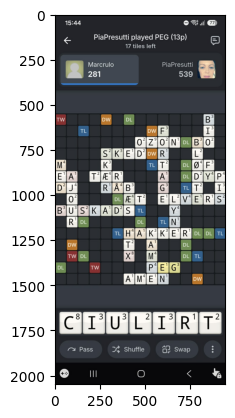

In [5]:
plt.imshow(plt.imread(path))
plt.show()

<Axes: >

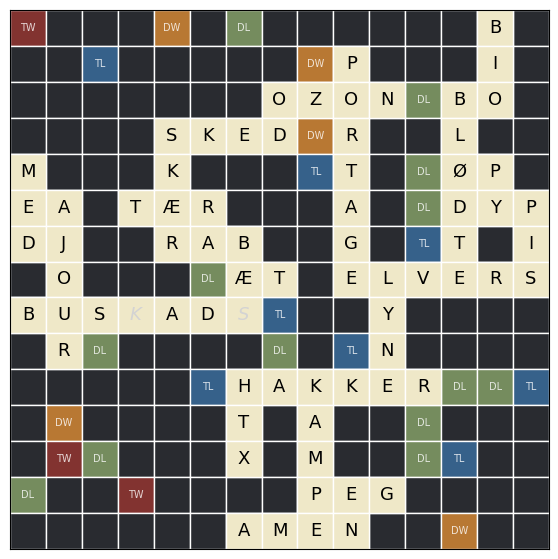

In [6]:
# print board
plot_board(letters, bonus, board_blanks=board_blanks)


## 2. Build the engine and pick the policy
Default is the **2-ply lookahead** agent: for each candidate it simulates the
opponent's reply over racks sampled from the unseen-tile pool and picks the move
with the best `score − E[opponent reply]`. It plays defense (avoids opening
premium squares) and beats greedy with no training. `n_samples` / `max_candidates`
trade accuracy for speed.

In [7]:
import random
from src.lookahead import LookaheadAgent

words = [w for lst in load_dictionary().values() for w in lst]
engine = WordfeudEngine(words)

agent = LookaheadAgent(n_samples=50, max_candidates=12, rng=random.Random(0))
print("using 2-ply Monte-Carlo lookahead policy")

using 2-ply Monte-Carlo lookahead policy


## 3. Top 10 moves (ranked)
A ranked fallback list of **distinct words** — if the official Wordfeud app
rejects the #1 word (its dictionary may differ from ours), try the next.
`value` = lookahead score net of the opponent's expected reply; `score` = raw
points; `E[opp]` = opponent's expected best reply.

In [8]:
top = agent.top_moves(engine, letters, bonus, rack, n=10, board_blanks=board_blanks)

print(f"{'#':>2}  {'word':<12} {'dir':<3} {'start':<8} {'score':>5} {'value':>6} {'E[opp]':>6}")
print("-" * 50)
for t in top:
    print(f"{t['rank']:>2}  {t['word']:<12} {t['direction']:<3} "
          f"{str(t['start']):<8} {t['score']:>5} {t['value']:>6} {t['exp_opp']:>6}")

print("\nTo play #1 in the app, place these tiles (row, col, letter):")
for r, c, ch in top[0]["tiles"]:
    print(f"  ({r:2d}, {c:2d})  {ch.upper()}")

 #  word         dir start    score  value E[opp]
--------------------------------------------------
 1  lynet        V   (7, 10)     33   -5.0   38.0
 2  tilskær      V   (0, 4)      34   -6.5   40.5
 3  lyner        V   (7, 10)     23  -12.5   35.0
 4  urt          H   (12, 10)    17  -13.0   29.0
 5  url          H   (12, 10)    17  -14.7   30.7
 6  pistil       V   (5, 14)     20  -15.7   35.7
 7  pist         V   (5, 14)     20  -15.7   35.2
 8  sic          V   (8, 2)      23  -15.9   38.4
 9  tri          V   (1, 14)     17  -16.3   33.3
10  curl         H   (1, 4)      20  -16.7   35.2

To play #1 in the app, place these tiles (row, col, letter):
  (11, 10)  T
  (11, 11)  I
  (11, 12)  C


## 4. Visualise the ranked moves
Each board highlights one candidate's tiles, in rank order.

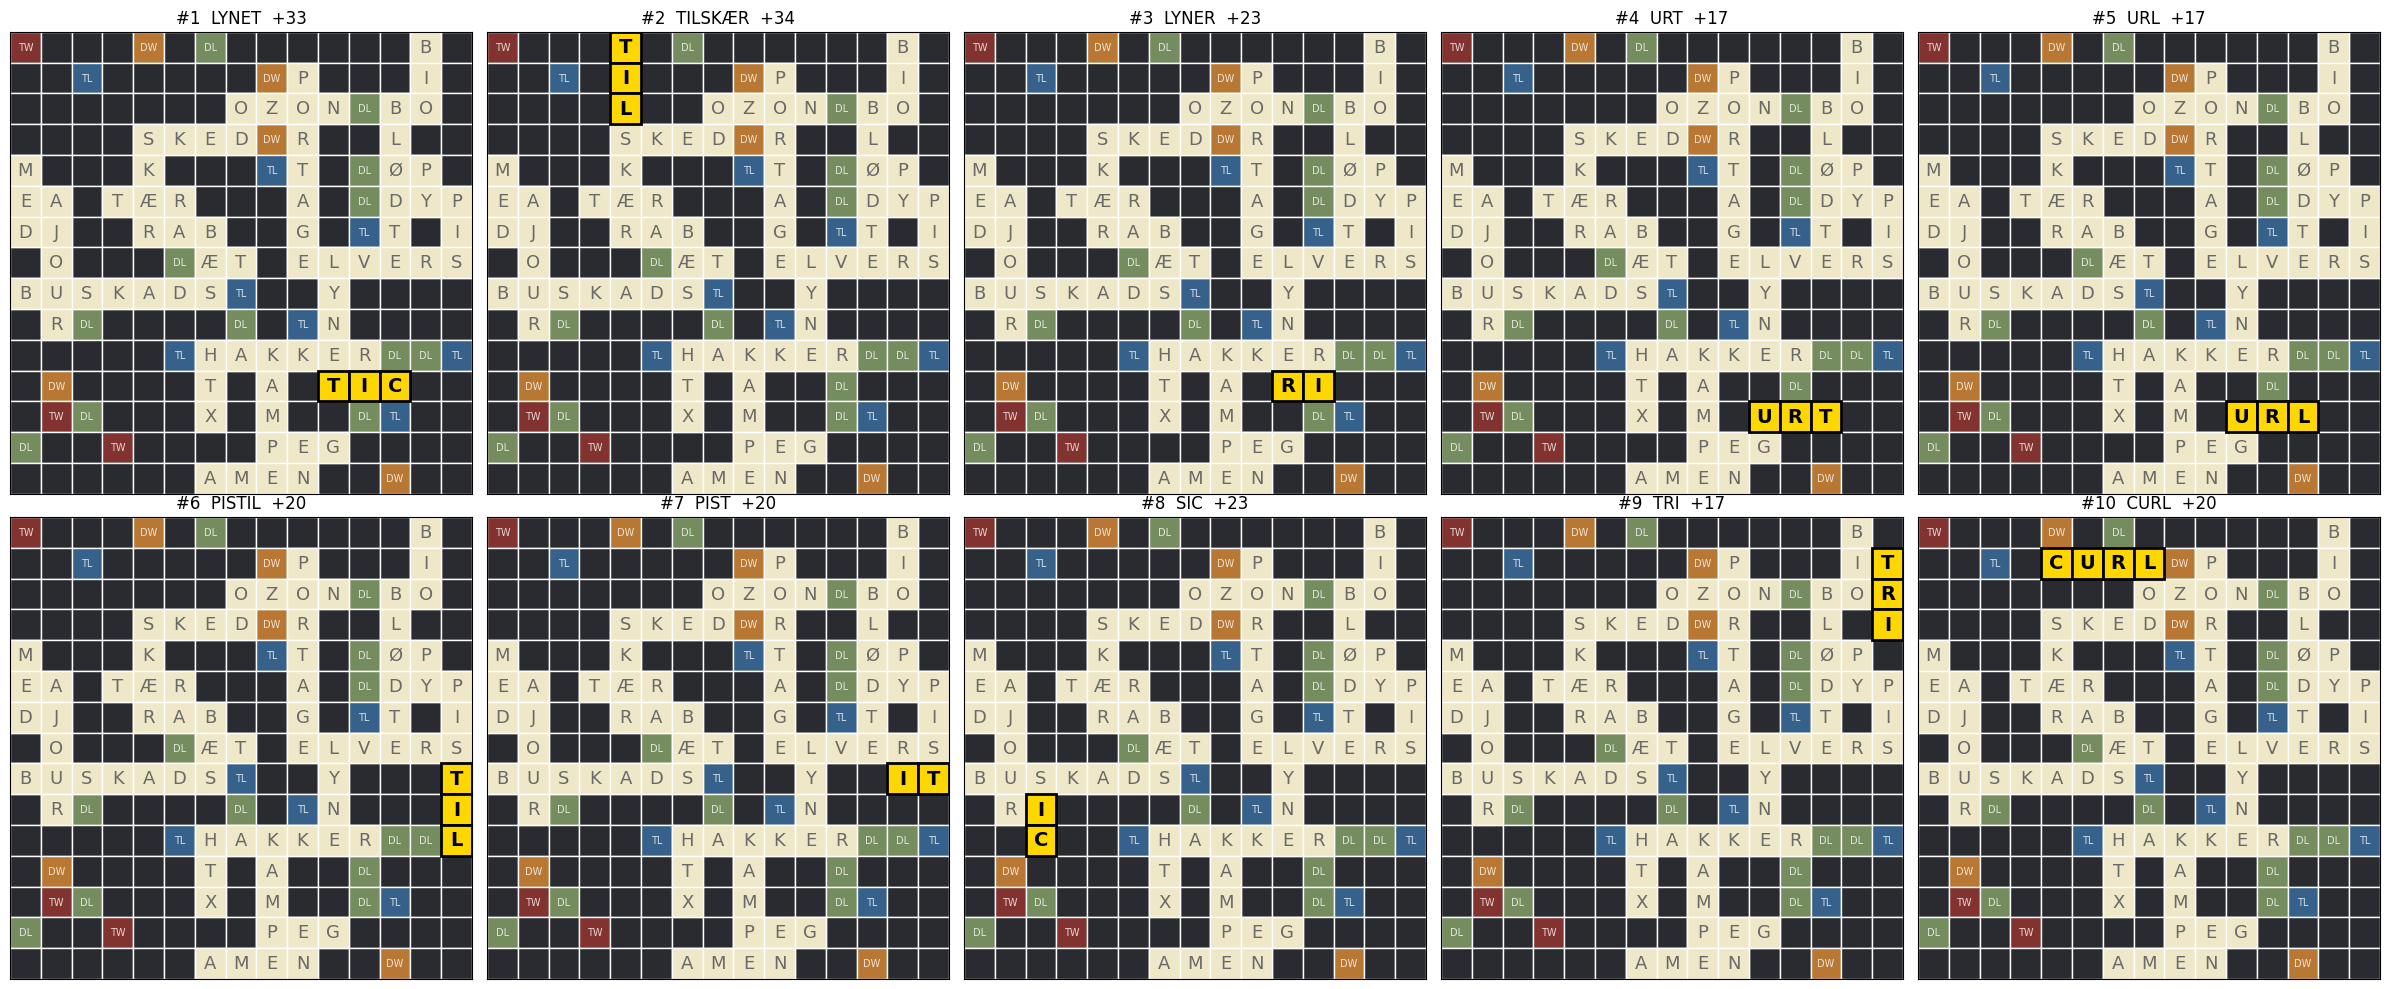

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
for t, ax in zip(top, axes.ravel()):
    plot_board(letters, bonus, move=t["move"], ax=ax,
               title=f"#{t['rank']}  {t['word'].upper()}  +{t['score']}")
for ax in axes.ravel()[len(top):]:
    ax.axis("off")
plt.tight_layout()
plt.show()